# Amazon review NLP

## 1 Prepare environment

In [1]:
# Data loading
import json
import pandas as pd

In [2]:
# General processing
from tqdm import tqdm
tqdm.pandas()
from IPython.display import clear_output

In [3]:
# NLP
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from afinn import Afinn
from bertopic import BERTopic

In [4]:
# Visualisation
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

## 2 Dataset

### 2.0 Back up / read in backed-up data

### 2.1 Explore raw data

In [5]:
# See how many lines are in the dataset
json_lines = 0

with open('.data/Office_Products.jsonl', 'r') as fp:
    for line in fp:
        json_lines = json_lines + 1

In [6]:
# See how data is structured in the dataset
with open('.data/Office_Products.jsonl', 'r') as fp:
    for line in fp:
        test_dict = json.loads(line)
        break

test_dict

{'rating': 5.0,
 'title': 'Pretty & I love it!',
 'text': 'Lovely ink. Writes well. The right amount of wet/dry. Currently using it in both a platinum curidas (f) & a pelican twist (m) & it writes well in both.  Beautiful color & flows nicely. It has not clogged up my nibs.',
 'images': [],
 'asin': 'B01AHHL4X2',
 'parent_asin': 'B01MZ3SD2X',
 'user_id': 'AFKZENTNBQ7A7V7UXW5JJI6UGRYQ',
 'timestamp': 1677939345945,
 'helpful_vote': 0,
 'verified_purchase': True}

In [7]:
# Choose columns of interest
cols = ['rating', 'text', 'parent_asin']

### 2.2 Read in raw data

In [8]:
# Set up lists for batches
intermediate_batch = []
max_batch_size = 100000
intermediate_dfs = []

# Read in data batch-wise
with open('.data/Office_Products.jsonl', 'r') as f:
    for line in tqdm(f, total=json_lines):
        r = json.loads(line)
        intermediate_batch.append({c: r.get(c) for c in cols})
        if len(intermediate_batch) == max_batch_size:
            intermediate_dfs.append(pd.DataFrame(intermediate_batch))
            intermediate_batch.clear()
clear_output()

# Add final non-full batch
if len(intermediate_batch) != 0:
    intermediate_dfs.append(pd.DataFrame(intermediate_batch))
    intermediate_batch.clear()

# Append batches
raw_reviews = pd.concat(intermediate_dfs, ignore_index=True)
intermediate_dfs.clear()

### 2.3 Explore raw data

In [9]:
# Info
raw_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12845712 entries, 0 to 12845711
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   rating       float64
 1   text         object 
 2   parent_asin  object 
dtypes: float64(1), object(2)
memory usage: 294.0+ MB


In [10]:
# Top 5 reviews
raw_reviews.head()

,rating,text,parent_asin
0,5.0,Lovely ink. Writes well. The right amount of w...,B01MZ3SD2X
1,4.0,Overall I’m pretty happy with this purchase bc...,B08L6H23JZ
2,1.0,[[VIDEOID:63276c19932aa4f3687042b8b9f8613c]] U...,B07JDZ5J46
3,4.0,"It’s a beautiful color, but even though it had...",B07BR2PBJN
4,3.0,Idk if I just got a bad batch which is possibl...,B097SFY5ZS


In [11]:
# Reviews containing nas
raw_reviews[raw_reviews.isna().any(axis=1)]

,rating,text,parent_asin


## 3 Clean data

### 3.1 Clean ratings

<Axes: xlabel='rating'>

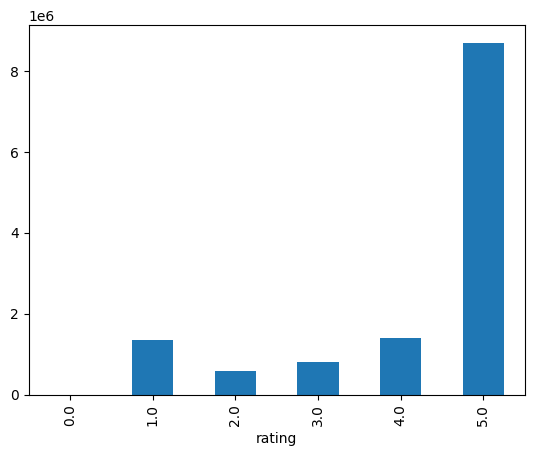

In [12]:
# Observe ratings
raw_reviews['rating'].value_counts().sort_index().plot.bar()

In [13]:
# Remove erroneous reviews
raw_reviews = raw_reviews.loc[raw_reviews['rating'] != 0.0]

In [14]:
# Normalise ratings around -1 to 1
raw_reviews['normalised_rating'] = (raw_reviews['rating'] - 3 ) / 2

In [15]:
# Classify rating
def rating_classification(score):
    if score > 0:
        return 'Positive'
    elif score < 0:
        return 'Negative'
    else:
        return 'Neutral'

raw_reviews['rating_classification'] = raw_reviews['normalised_rating'].progress_apply(rating_classification)

clear_output()

### 3.2 Clean text

In [16]:
# Reviews containing non-alphanumeric characters (printing because text is often long)
i = 0
for index, text in raw_reviews.loc[raw_reviews['text'].str.contains(r'[^a-zA-Z0-9\s]'), 'text'].items():
    if i == 10:
        break
    print(text)
    i = i + 1

Lovely ink. Writes well. The right amount of wet/dry. Currently using it in both a platinum curidas (f) & a pelican twist (m) & it writes well in both.  Beautiful color & flows nicely. It has not clogged up my nibs.
Overall I’m pretty happy with this purchase bc the ink is good & I’ve purchased it before.  The green is gorgeous.  The purple didn’t really wow me, but it flows nicely. The blue however is a disappointment bc it’s extremely dry & keeps drying in my pen. I am using the inks in the same type of pen- platinum curidas & all have same size nib. So the only difference is the actual ink.  I’m gonna try to mix a little of the ink with a tiny bit of glycerin next time I refill it & see if that helps it to stay wetter & not dry out in my pen. Aside from that I love their ink. Think I just received a dud this time with the blue.
[[VIDEOID:63276c19932aa4f3687042b8b9f8613c]] Update: tried again to return them. I have prime. Amazon wants $7.99 to pick them up. Why? Bc I return garbage p

#### 3.2.1 Embedded references

In [17]:
# Remove text contained by and including "[[" and "]]"
raw_reviews['text'] = raw_reviews['text'].str.replace(r'\[\[.*?\]\]', '', regex=True)

#### 3.2.2 HTML code

In [18]:
# Remove text contained by and including "<" and ">"
raw_reviews['text'] = raw_reviews['text'].str.replace(r'\<.*?\>', '', regex=True)

#### 3.2.3 Links

In [19]:
# Reviews with links
i = 0
for index, text in raw_reviews.loc[raw_reviews['text'].str.contains(r'https?://\S+|www\.\S+'), 'text'].items():
    if i == 10:
        break
    print(text)
    i = i + 1

Don't buy this.  Get the same printer but with the document feeder (and fax) for the same price here:https://www.amazon.com/dp/B00C6MNQ92?ref=emc_b_5_t
This calendar is exactly what I've been wanting! I had another one but the wood was too light for my home decor and it just didn't fit in that well. This calendar is a dark wood exactly as described and pictured and is the perfect addition to my home! In my picture, it can be seen hanging over the bin I purchased (bin link here: https://www.amazon.com/gp/product/B07V44MXWX/ref=ppx_yo_dt_b_asin_title_o03_s00?ie=UTF8&psc=1) to hold all the birthday cards. Together they are the perfect "Birthday Central" in my hallway making it "stupid easy", as my husband likes to say, to keep up with everyone. LOL!With 4 children (and their spouses), 9 grandchildren and our parents and siblings.. this calendar is a life saver! It is lightweight so I can hang it pretty much anywhere. I like the little wooden disks and hearts, they are not too big or too s

In [20]:
# Remove links from reviews
raw_reviews['text'] = raw_reviews['text'].str.replace(r'https?://\S+|www\.\S+', '', regex=True)

#### 3.2.4 No letters

In [21]:
# Reviews not containing letters (no need to print)
raw_reviews.loc[raw_reviews['text'].str.contains(r'^[^a-zA-Z]*$'), 'text'].value_counts()

text
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  12207
                                                                                                                           

In [22]:
# Remove reviews not containing letters
raw_reviews = raw_reviews.loc[~raw_reviews['text'].str.contains(r'^[^a-zA-Z]*$')]

### 3.3 Product-level cleaning

In [23]:
# Count of review classification by product
rating_classification_product_counts = raw_reviews.groupby(['parent_asin', 'rating_classification']).size().unstack(fill_value=0)

In [24]:
# Remove reviews of products with fewer than 10 of each type of review
valid_asins = rating_classification_product_counts[(rating_classification_product_counts >= 10).all(axis=1)].index
raw_reviews = raw_reviews[raw_reviews['parent_asin'].isin(valid_asins)]

array([[<Axes: title={'center': 'rating'}>]], dtype=object)

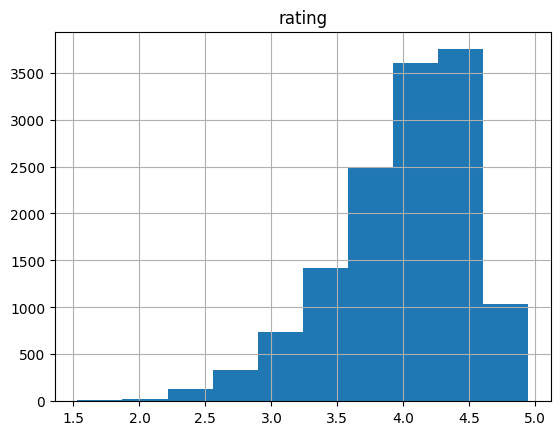

In [25]:
# Distribution of mean reviews by product
mean_ratings = raw_reviews[['parent_asin', 'rating']].groupby('parent_asin').mean()

mean_ratings.hist()

## 4 Text preprocessing

In [26]:
# Change to lowercase and remove non alphabetical/space characters
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

raw_reviews['cleaned_text'] = raw_reviews['text'].progress_apply(clean_text)

clear_output()

In [27]:
# Tokenize text
from nltk.tokenize import word_tokenize

raw_reviews['tokens'] = raw_reviews['cleaned_text'].progress_apply(word_tokenize)

clear_output()

In [28]:
# Remove stopwords
english_stopwords = set(nltk.corpus.stopwords.words('english'))

def remove_stopwords(tokens):
    return [token for token in tokens if token not in english_stopwords]

raw_reviews['no_stopword_tokens'] = raw_reviews['tokens'].progress_apply(remove_stopwords)

clear_output()

## 5 Sentiment analysis

### 5.1 Lexicon scoring

In [29]:
# Normalised Afinn score
afinn = Afinn()

def normalised_afinn(text):
    afinn_score = afinn.score(text)
    token_count = len(text.split())
    return (afinn_score / token_count) / 5

raw_reviews['afinn_score'] = raw_reviews['cleaned_text'].progress_apply(normalised_afinn)

clear_output()

<Axes: >

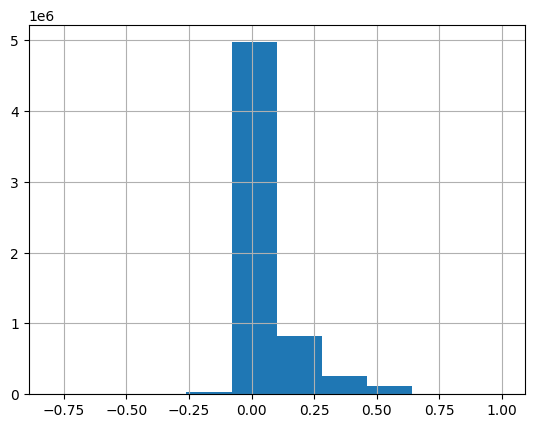

In [30]:
raw_reviews['afinn_score'].hist()

<Axes: >

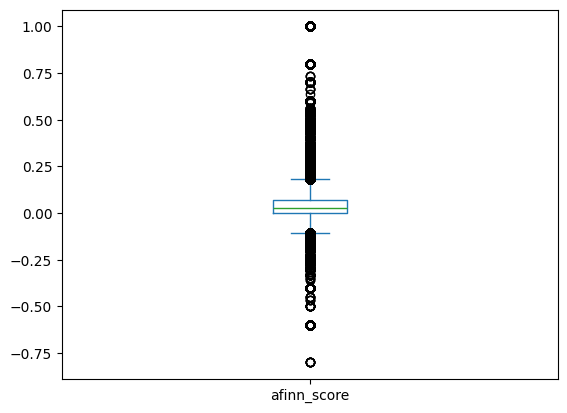

In [31]:
raw_reviews['afinn_score'].plot.box()

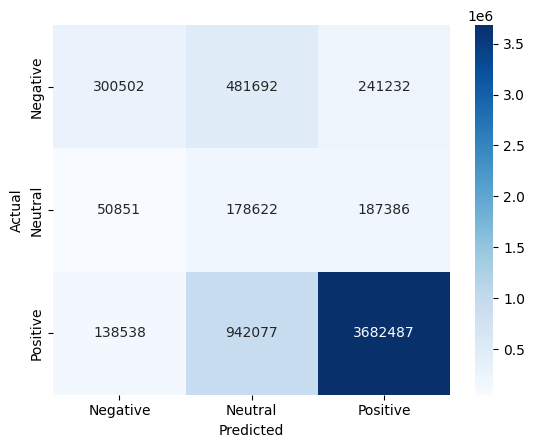

In [32]:
# Classify Afinn score
def afinn_classification(score):
    if score >= 0.01:
        return 'Positive'
    elif score <= -0.01:
        return 'Negative'
    else:
        return 'Neutral'

raw_reviews['afinn_classification'] = raw_reviews['afinn_score'].progress_apply(afinn_classification)

clear_output()

confusion = pd.crosstab(
    raw_reviews["rating_classification"],
    raw_reviews["afinn_classification"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.show()

### 5.2 VADER scoring

In [ ]:
# Generate VADER score
sia = SentimentIntensityAnalyzer()

def vader_sentiment(text):
    return sia.polarity_scores(text)['compound']

raw_reviews['vader_score'] = raw_reviews['cleaned_text'].progress_apply(vader_sentiment)

clear_output()

 12%|████████▋                                                              | 759400/6203387 [01:57<14:56, 6073.74it/s]

In [ ]:
raw_reviews['vader_score'].hist()

In [ ]:
# Classify VADER score
def vader_classification(score):
    if score >= 0.2:
        return 'Positive'
    elif score <= -0.2:
        return 'Negative'
    else:
        return 'Neutral'

raw_reviews['vader_classification'] = raw_reviews['vader_score'].progress_apply(vader_classification)

clear_output()

confusion = pd.crosstab(
    raw_reviews["rating_classification"],
    raw_reviews["vader_classification"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.show()

## 6 Topic classification

### 6.1 Choosing the product

In [ ]:
popular_product_all_reviews = raw_reviews[raw_reviews['parent_asin'] == raw_reviews['parent_asin'].value_counts().index[0]]

In [ ]:
popular_product_all_reviews['rating_classification'].value_counts().sort_index(ascending=False).plot.bar()

In [ ]:
confusion = pd.crosstab(
    popular_product_all_reviews["rating_classification"],
    popular_product_all_reviews["afinn_classification"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.show()

In [ ]:
confusion = pd.crosstab(
    popular_product_all_reviews["rating_classification"],
    popular_product_all_reviews["vader_classification"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.show()

### 6.2 Perform modelling

In [ ]:
popular_product_positive_reviews = popular_product_all_reviews[(popular_product_all_reviews['rating_classification'] == 'Positive') & (popular_product_all_reviews['afinn_classification'] == 'Positive') & (popular_product_all_reviews['vader_classification'] == 'Positive')]
popular_product_negative_reviews = popular_product_all_reviews[(popular_product_all_reviews['rating_classification'] == 'Negative') & (popular_product_all_reviews['afinn_classification'] == 'Negative') & (popular_product_all_reviews['vader_classification'] == 'Negative')]

In [ ]:
reviews = popular_product_negative_reviews['cleaned_text']
topic_model = BERTopic(language='english')
topics, probs = topic_model.fit_transform(reviews)
popular_product_negative_reviews['topic'] = topics

In [ ]:
popular_product_negative_reviews['topic'].value_counts()

In [ ]:
topic_model.get_topic_info().set_index('Topic')